### Pipeline tổng quan

```
file ảnh gốc (JPEG/PNG)
  → Đọc thành ma trận pixel
  → Fix EXIF orientation
  → Xóa metadata (EXIF, ICC, XMP)
  → Chuyển không gian màu BGR → YCrCb
  → Center crop 256×256
  → Lưu PNG (lossless)
  → Trích xuất đặc trưng (FFT, GLCM, Residual, Color correlation)
  → Train mô hình phân loại (Random Forest, XGBoost)
```

### Dữ liệu
- **7 generators** AI: ADM, GLIDE, Midjourney, SDv14, SDv15, VQDM, Wukong
- Mỗi generator có thư mục ảnh **real** (ảnh gốc tương ứng) và **fake** (ảnh AI sinh ra)

### Tại sao tiền xử lí quan trọng?
- Ảnh gốc có **kích thước khác nhau**, format khác nhau → cần **chuẩn hóa**
- Metadata (EXIF) có thể chứa dấu hiệu "gian lận" (ví dụ: `Software: Stable Diffusion`) → cần **xóa** để model học từ pixel, không từ metadata
- Không gian màu **YCrCb** tách biệt thông tin sáng (Y) và màu (Cr, Cb) → tốt hơn cho phân tích texture và tần số
- Center crop thay vì resize → **giữ nguyên cấu trúc pixel**, không tạo artifact nội suy

## Phần 1: Cấu hình & Import thư viện

In [3]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thêm thư mục gốc vào path để import src/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

# ============ CẤU HÌNH ============
RAW_DIR   = r"E:\ai_image_detector\data\raw"
RAW_REAL  = os.path.join(RAW_DIR, "real")
RAW_FAKE  = os.path.join(RAW_DIR, "fake")
PROC_DIR  = r"E:\ai_image_detector\data\processed"
PROC_REAL = os.path.join(PROC_DIR, "real")
PROC_FAKE = os.path.join(PROC_DIR, "fake")

IMG_SIZE  = 256   # Kích thước output sau center crop
MIN_SIZE  = 64    # Ảnh nhỏ hơn sẽ bị loại

GENERATORS = ["ADM", "GLIDE", "Midjourney", "SDv14", "SDv15", "VQDM", "Wukong"]

os.makedirs(PROC_REAL, exist_ok=True)
os.makedirs(PROC_FAKE, exist_ok=True)

print(f"Raw directory:       {RAW_DIR}")
print(f"Processed directory: {PROC_DIR}")
print(f"Output size:         {IMG_SIZE}×{IMG_SIZE}")
print(f"Min size filter:     {MIN_SIZE}×{MIN_SIZE}")
print(f"Generators:          {GENERATORS}")


Raw directory:       E:\ai_image_detector\data\raw
Processed directory: E:\ai_image_detector\data\processed
Output size:         256×256
Min size filter:     64×64
Generators:          ['ADM', 'GLIDE', 'Midjourney', 'SDv14', 'SDv15', 'VQDM', 'Wukong']


---
## Phần 2: Khám phá dữ liệu thô (EDA)

### 2.1 Thống kê số lượng ảnh theo generator và nhãn

Đầu tiên cần nắm được:
- Tổng bao nhiêu ảnh?
- Mỗi generator có bao nhiêu ảnh real / fake?
- Dữ liệu có **cân bằng** (balanced) giữa real và fake không?

Nếu dữ liệu mất cân bằng nghiêm trọng, model có thể **thiên lệch** về lớp đa số.

In [4]:
rows = []
for gen in GENERATORS:
    real_path = os.path.join(RAW_REAL, gen)
    fake_path = os.path.join(RAW_FAKE, gen)

    real_count = len(os.listdir(real_path)) 
    fake_count = len(os.listdir(fake_path))
    rows.append({
        "Generator": gen,
        "Real": real_count,
        "Fake": fake_count,
        "Total": real_count + fake_count
    })

df = pd.DataFrame(rows)

print(df.to_string(index=False))
print("\nTotal Real:", df["Real"].sum())
print("Total Fake:", df["Fake"].sum())
print("Total Images:", df["Total"].sum())

 Generator  Real  Fake  Total
       ADM  6000  6000  12000
     GLIDE  6000  6000  12000
Midjourney  6000  6000  12000
     SDv14  6000  6000  12000
     SDv15  8000  8000  16000
      VQDM  6000  6000  12000
    Wukong  6000  6000  12000

Total Real: 44000
Total Fake: 44000
Total Images: 88000


### 2.2 Kiểm tra kích thước & định dạng ảnh

Trước khi xử lý, cần biết:
- Ảnh có **kích thước đồng nhất** không? (hay mỗi ảnh một size?)
- Có ảnh nào **quá nhỏ** (< 64px) hoặc **không đọc được** (corrupt)?
- File dùng format gì? (.PNG, .JPEG, .jpg?)

Nếu kích thước khác nhau, bước **center crop** ở sau sẽ giải quyết. Ảnh nhỏ hơn 256×256 sẽ bị loại vì không đủ lớn để crop.

KIỂM TRA KÍCH THƯỚC & ĐỊNH DẠNG
Tổng ảnh kiểm tra: 2800
Ảnh đọc được:      2800
Ảnh corrupt:        0

Phân phối định dạng file:
  .JPEG: 1400
  .PNG: 1400

Kích thước (Width):
  Min:  74
  Max:  2522
  Mean: 483

Kích thước (Height):
  Min:  56
  Max:  2806
  Mean: 453

Ảnh nhỏ hơn 256×256: 55 (2.0%)


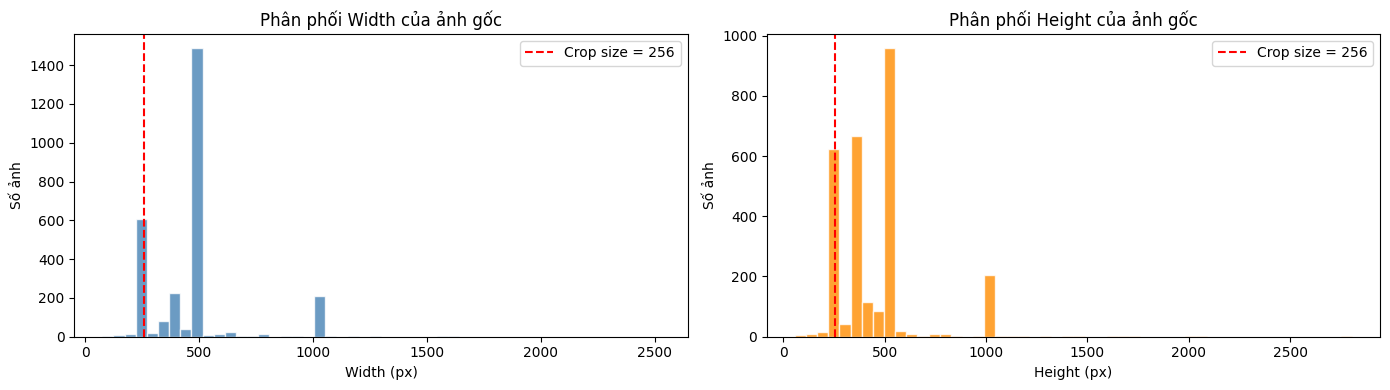

In [5]:
# === 2.2 Kiểm tra kích thước & định dạng ảnh (sample) ===

import random
random.seed(42)

size_records = []
extensions = defaultdict(int)
corrupt_files = []
sample_limit = 200  # Lấy tối đa 200 ảnh/generator để kiểm tra nhanh

for label_name, raw_dir in [("real", RAW_REAL), ("fake", RAW_FAKE)]:
    for gen in GENERATORS:
        gen_path = os.path.join(raw_dir, gen)
        if not os.path.isdir(gen_path):
            continue
        
        files = os.listdir(gen_path)
        sampled = random.sample(files, min(sample_limit, len(files)))
        
        for fname in sampled:
            fpath = os.path.join(gen_path, fname)
            ext = os.path.splitext(fname)[1].upper()
            extensions[ext] += 1
            
            img = cv2.imread(fpath)
            if img is None:
                corrupt_files.append(fpath)
                continue
            
            h, w = img.shape[:2]
            size_records.append({
                "label": label_name,
                "generator": gen,
                "width": w,
                "height": h,
                "filename": fname
            })

df_sizes = pd.DataFrame(size_records)

# Tóm tắt
print("=" * 55)
print("KIỂM TRA KÍCH THƯỚC & ĐỊNH DẠNG")
print("=" * 55)
print(f"Tổng ảnh kiểm tra: {len(size_records) + len(corrupt_files)}")
print(f"Ảnh đọc được:      {len(size_records)}")
print(f"Ảnh corrupt:        {len(corrupt_files)}")

print(f"\nPhân phối định dạng file:")
for ext, count in sorted(extensions.items(), key=lambda x: -x[1]):
    print(f"  {ext}: {count}")

print(f"\nKích thước (Width):")
print(f"  Min:  {df_sizes['width'].min()}")
print(f"  Max:  {df_sizes['width'].max()}")
print(f"  Mean: {df_sizes['width'].mean():.0f}")

print(f"\nKích thước (Height):")
print(f"  Min:  {df_sizes['height'].min()}")
print(f"  Max:  {df_sizes['height'].max()}")
print(f"  Mean: {df_sizes['height'].mean():.0f}")

too_small = df_sizes[(df_sizes['width'] < IMG_SIZE) | (df_sizes['height'] < IMG_SIZE)]
print(f"\nẢnh nhỏ hơn {IMG_SIZE}×{IMG_SIZE}: {len(too_small)} ({len(too_small)/len(df_sizes)*100:.1f}%)")

if len(corrupt_files) > 0:
    print(f"\n⚠️ File corrupt (mẫu):")
    for f in corrupt_files[:5]:
        print(f"  {f}")

# Histogram kích thước
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_sizes['width'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=IMG_SIZE, color='red', linestyle='--', label=f'Crop size = {IMG_SIZE}')
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Số ảnh")
axes[0].set_title("Phân phối Width của ảnh gốc")
axes[0].legend()

axes[1].hist(df_sizes['height'], bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(x=IMG_SIZE, color='red', linestyle='--', label=f'Crop size = {IMG_SIZE}')
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Số ảnh")
axes[1].set_title("Phân phối Height của ảnh gốc")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.3 Kiểm tra trùng lặp tên file

Vì có 7 generator, mỗi generator có thư mục riêng, **tên file có thể trùng** giữa các generator khác nhau.

Ví dụ: `0_adm_153.PNG` có thể xuất hiện cả trong `real/ADM/` và `fake/ADM/`.

Nếu khi lưu vào `processed/` không phân biệt generator → **file bị ghi đè** → mất dữ liệu.

**Giải pháp**: Prefix tên file output với `{generator}_` để đảm bảo duy nhất.

In [6]:
# === 2.3 Kiểm tra trùng lặp tên file cross-generator ===

for label_name, raw_dir in [("real", RAW_REAL), ("fake", RAW_FAKE)]:
    name_map = defaultdict(list)
    for gen in GENERATORS:
        gen_path = os.path.join(raw_dir, gen)
        if not os.path.isdir(gen_path):
            continue
        for fname in os.listdir(gen_path):
            base = os.path.splitext(fname)[0]  # bỏ extension
            name_map[base].append(gen)
    
    dups = {k: v for k, v in name_map.items() if len(v) > 1}
    print(f"[{label_name.upper()}] Tổng tên file duy nhất: {len(name_map)}")
    print(f"[{label_name.upper()}] Tên trùng giữa generators: {len(dups)}")
    if dups:
        sample = list(dups.items())[:3]
        for name, gens in sample:
            print(f"  Ví dụ: '{name}' → xuất hiện ở: {gens}")
    print()

[REAL] Tổng tên file duy nhất: 44000
[REAL] Tên trùng giữa generators: 0

[FAKE] Tổng tên file duy nhất: 44000
[FAKE] Tên trùng giữa generators: 0



### 2.4 Hiển thị ảnh mẫu từ mỗi generator

Nhìn trực quan vào dữ liệu: mỗi generator hiện **1 ảnh real** và **1 ảnh fake** để so sánh. Đây là bước quan trọng trong EDA — giúp hiểu dữ liệu đang làm việc với cái gì.

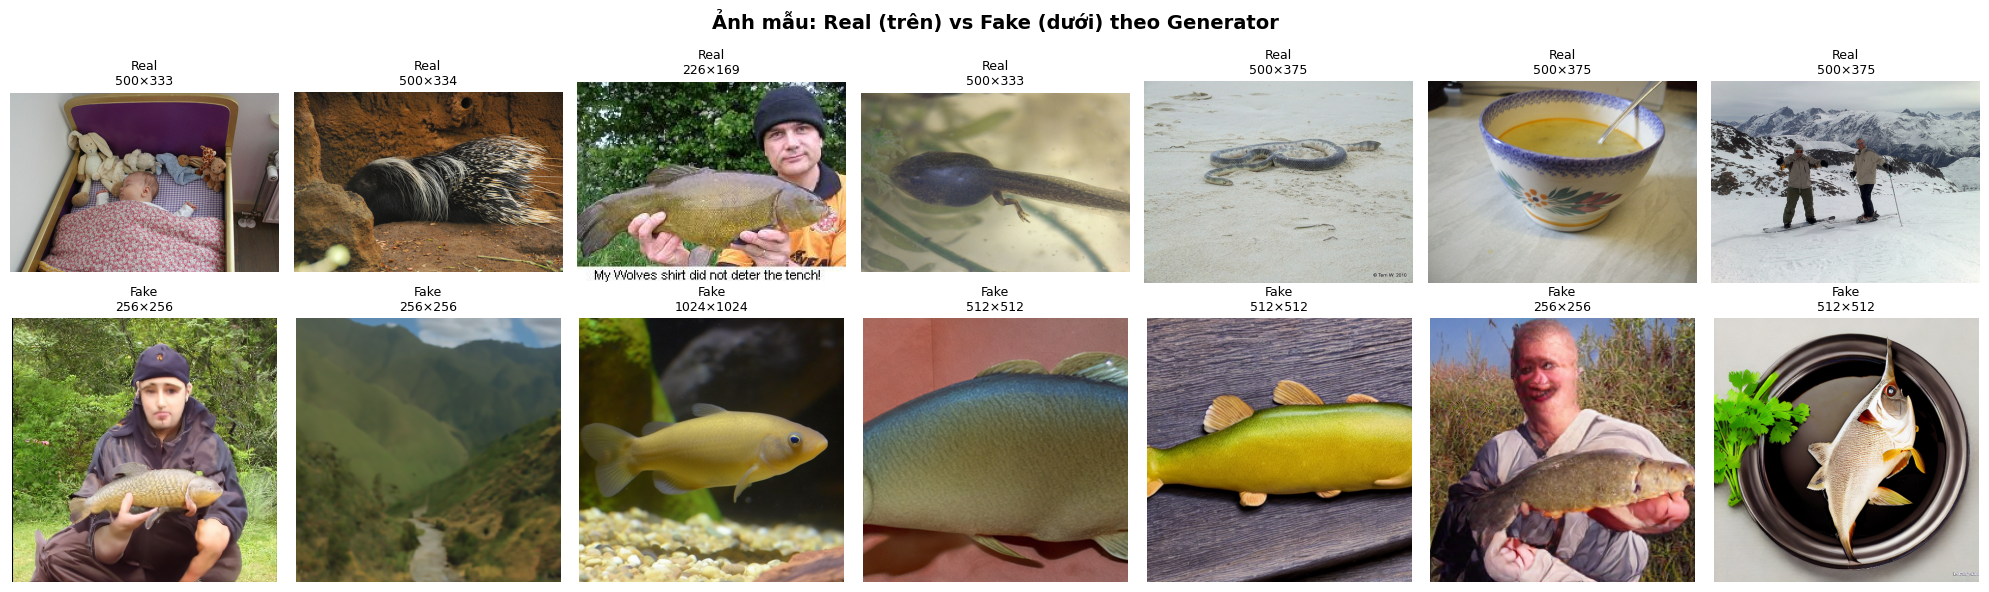

In [7]:
# === 2.4 Hiển thị ảnh mẫu: 1 real + 1 fake mỗi generator ===

fig, axes = plt.subplots(2, len(GENERATORS), figsize=(20, 6))

for col, gen in enumerate(GENERATORS):
    for row, (label_name, raw_dir) in enumerate([("Real", RAW_REAL), ("Fake", RAW_FAKE)]):
        gen_path = os.path.join(raw_dir, gen)
        if not os.path.isdir(gen_path):
            axes[row, col].set_visible(False)
            continue
        
        files = os.listdir(gen_path)
        if not files:
            axes[row, col].set_visible(False)
            continue
        
        # Lấy ảnh đầu tiên
        fpath = os.path.join(gen_path, files[0])
        img = cv2.imread(fpath)
        
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(img_rgb)
            h, w = img.shape[:2]
            axes[row, col].set_title(f"{label_name}\n{w}×{h}", fontsize=9)
        else:
            axes[row, col].text(0.5, 0.5, "Corrupt", ha='center', va='center')
        
        axes[row, col].axis('off')
        
        if col == 0:
            axes[row, col].set_ylabel(label_name, fontsize=12, fontweight='bold')

# Thêm tên generator ở trên
for col, gen in enumerate(GENERATORS):
    axes[0, col].set_xlabel(gen, fontsize=10)

plt.suptitle("Ảnh mẫu: Real (trên) vs Fake (dưới) theo Generator", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Phân tích pixel thống kê sơ bộ

So sánh **phân phối giá trị pixel** giữa ảnh real và fake. Nếu có sự khác biệt rõ rệt ở mức pixel cơ bản, điều này cho thấy dấu hiệu mà mô hình có thể khai thác.

Lưu ý: phân tích này ở mức rất sơ bộ (mean, std). Các đặc trưng phức tạp hơn (FFT, GLCM...) sẽ được trích xuất ở Notebook 02.

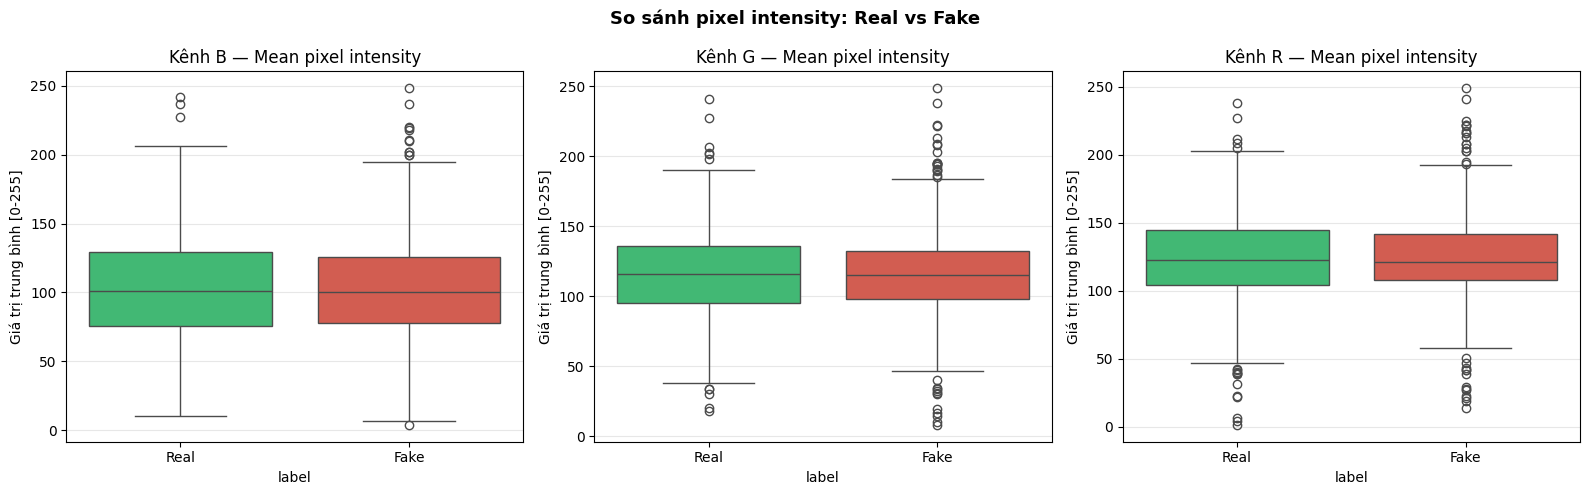


=== THỐNG KÊ PIXEL TRUNG BÌNH ===
       overall_mean  overall_std
label                           
Fake         114.94        61.81
Real         114.40        62.81


In [8]:
# === 2.5 Phân tích pixel thống kê sơ bộ ===

pixel_stats = []
n_sample = 50  # Lấy 50 ảnh mỗi generator/label

for label_name, raw_dir in [("Real", RAW_REAL), ("Fake", RAW_FAKE)]:
    for gen in GENERATORS:
        gen_path = os.path.join(raw_dir, gen)
        if not os.path.isdir(gen_path):
            continue
        
        files = os.listdir(gen_path)
        sampled = random.sample(files, min(n_sample, len(files)))
        
        for fname in sampled:
            img = cv2.imread(os.path.join(gen_path, fname))
            if img is None:
                continue
            pixel_stats.append({
                "label": label_name,
                "generator": gen,
                "mean_B": img[:,:,0].mean(),
                "mean_G": img[:,:,1].mean(),
                "mean_R": img[:,:,2].mean(),
                "std_B": img[:,:,0].std(),
                "std_G": img[:,:,1].std(),
                "std_R": img[:,:,2].std(),
                "overall_mean": img.mean(),
                "overall_std": img.std()
            })

df_pixel = pd.DataFrame(pixel_stats)

# Boxplot: mean pixel intensity real vs fake
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (ch, color) in enumerate([("mean_B", "blue"), ("mean_G", "green"), ("mean_R", "red")]):
    sns.boxplot(data=df_pixel, x="label", y=ch, ax=axes[i], palette=["#2ecc71", "#e74c3c"])
    axes[i].set_title(f"Kênh {ch[-1]} — Mean pixel intensity")
    axes[i].set_ylabel("Giá trị trung bình [0-255]")
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle("So sánh pixel intensity: Real vs Fake", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tóm tắt số
print("\n=== THỐNG KÊ PIXEL TRUNG BÌNH ===")
print(df_pixel.groupby("label")[["overall_mean", "overall_std"]].mean().round(2).to_string())

---
## Phần 2.6: Audit metadata dữ liệu RAW (trước tiền xử lí)

Mục tiêu của phần này là ghi nhận rõ trạng thái dữ liệu **trước khi preprocess** để đưa vào báo cáo:
- Ảnh có EXIF hay không.
- Các trường EXIF nhạy cảm (Make/Model/Software/Orientation/DateTime).
- Kích thước ảnh gốc và khả năng đọc file.

Đầu ra: `raw_metadata_audit.csv` trong thư mục `data/processed/`.

In [9]:
# === 2.6a Tạo bảng audit metadata cho dữ liệu RAW ===

import csv
from PIL import ExifTags

exif_id_to_name = {k: v for k, v in ExifTags.TAGS.items()}

def exif_get_by_name(exif, tag_name):
    for tag_id, value in exif.items():
        if exif_id_to_name.get(tag_id) == tag_name:
            return value
    return None


def normalize_csv_value(v):
    """Chuẩn hóa giá trị để ghi CSV an toàn."""
    if isinstance(v, bytes):
        return v.decode("utf-8", errors="replace")
    if isinstance(v, (list, tuple, dict, set)):
        return str(v)
    return v


raw_audit_rows = []

for label_name, raw_dir in [("real", RAW_REAL), ("fake", RAW_FAKE)]:
    for gen in GENERATORS:
        gen_path = os.path.join(raw_dir, gen)
        if not os.path.isdir(gen_path):
            continue

        for fname in os.listdir(gen_path):
            fpath = os.path.join(gen_path, fname)
            row = {
                "path": fpath,
                "label_name": label_name,
                "generator": gen,
                "filename": fname,
                "read_ok": False,
                "error_reason": None,
                "format": None,
                "mode": None,
                "width": None,
                "height": None,
                "has_exif": False,
                "exif_make": None,
                "exif_model": None,
                "exif_software": None,
                "exif_datetime": None,
                "exif_orientation": None,
            }

            try:
                with Image.open(fpath) as im:
                    row["read_ok"] = True
                    row["format"] = im.format
                    row["mode"] = im.mode
                    row["width"], row["height"] = im.size

                    exif = im.getexif()
                    if exif and len(exif) > 0:
                        row["has_exif"] = True
                        row["exif_make"] = exif_get_by_name(exif, "Make")
                        row["exif_model"] = exif_get_by_name(exif, "Model")
                        row["exif_software"] = exif_get_by_name(exif, "Software")
                        row["exif_datetime"] = exif_get_by_name(exif, "DateTime")
                        row["exif_orientation"] = exif_get_by_name(exif, "Orientation")

            except Exception as e:
                row["error_reason"] = str(e)

            raw_audit_rows.append(row)


df_raw_audit = pd.DataFrame(raw_audit_rows)

# Chuẩn hóa các cột dễ gây lỗi khi ghi CSV (bytes/object chứa ký tự đặc biệt)
for col in [
    "exif_make",
    "exif_model",
    "exif_software",
    "exif_datetime",
    "exif_orientation",
    "error_reason",
]:
    if col in df_raw_audit.columns:
        df_raw_audit[col] = df_raw_audit[col].map(normalize_csv_value)

raw_audit_path = os.path.join(PROC_DIR, "raw_metadata_audit.csv")
df_raw_audit.to_csv(
    raw_audit_path,
    index=False,
    encoding="utf-8-sig",
    quoting=csv.QUOTE_ALL,
    escapechar="\\",
)

print(f"✓ Đã lưu RAW metadata audit: {raw_audit_path}")
print(f"  Tổng số dòng: {len(df_raw_audit)}")

Error: need to escape, but no escapechar set

In [ ]:
# === 2.6b Summary trước tiền xử lí (RAW) ===

raw_ok = df_raw_audit[df_raw_audit["read_ok"] == True].copy()

pct_exif = 100.0 * raw_ok["has_exif"].mean() if len(raw_ok) else 0.0
pct_model = 100.0 * raw_ok["exif_model"].notna().mean() if len(raw_ok) else 0.0
pct_software = 100.0 * raw_ok["exif_software"].notna().mean() if len(raw_ok) else 0.0

summary_raw = pd.DataFrame([
    {"metric": "raw_total_files", "value": len(df_raw_audit)},
    {"metric": "raw_read_ok", "value": int(df_raw_audit["read_ok"].sum())},
    {"metric": "raw_has_exif_pct", "value": round(pct_exif, 2)},
    {"metric": "raw_has_model_pct", "value": round(pct_model, 2)},
    {"metric": "raw_has_software_pct", "value": round(pct_software, 2)},
    {"metric": "raw_width_min", "value": float(raw_ok["width"].min()) if len(raw_ok) else None},
    {"metric": "raw_width_median", "value": float(raw_ok["width"].median()) if len(raw_ok) else None},
    {"metric": "raw_width_max", "value": float(raw_ok["width"].max()) if len(raw_ok) else None},
    {"metric": "raw_height_min", "value": float(raw_ok["height"].min()) if len(raw_ok) else None},
    {"metric": "raw_height_median", "value": float(raw_ok["height"].median()) if len(raw_ok) else None},
    {"metric": "raw_height_max", "value": float(raw_ok["height"].max()) if len(raw_ok) else None},
])

print("=== TÓM TẮT RAW METADATA AUDIT ===")
print(summary_raw.to_string(index=False))

print("\nPreview 10 dòng để chụp báo cáo:")
df_raw_audit.head(10)

---
## Phần 3: Pipeline Tiền Xử Lí (Data Cleaning)

### Tổng quan các bước xử lí 1 ảnh

| Bước | Thao tác | Mục đích |
|------|----------|----------|
| 1 | Đọc ảnh bằng PIL | Truy cập cả pixel và metadata |
| 2 | Fix EXIF orientation | Đảm bảo ảnh đúng chiều (ảnh chụp xoay theo EXIF sẽ bị sai nếu đọc bằng code) |
| 3 | Convert sang RGB | Chuẩn hóa: bỏ alpha channel, xử lý grayscale |
| 4 | Chuyển sang numpy array | **Strip toàn bộ metadata** — model chỉ được nhìn pixel, không dựa vào EXIF/ICC/XMP |
| 5 | Kiểm tra kích thước | Loại ảnh quá nhỏ (< 64px) hoặc nhỏ hơn 256px (không đủ để crop) |
| 6 | Chuyển BGR → YCrCb | Y=sáng (tốt cho FFT/texture), Cr/Cb=màu (tốt cho color correlation) |
| 7 | Center crop 256×256 | Đồng nhất kích thước; giữ nguyên pixel thật, không nội suy |
| 8 | Lưu PNG | Lossless — không thêm artifact nén JPEG |


- **Y (Luminance)**: chứa hầu hết thông tin cấu trúc — cạnh, texture, chi tiết. Rất tốt cho phân tích FFT và GLCM.
- **Cr, Cb (Chrominance)**: thông tin màu, tách biệt khỏi sáng. Tốt cho phân tích tương quan màu.
- Trong JPEG, nén ảnh cũng hoạt động trên YCbCr → artifact nén xuất hiện rõ hơn ở không gian này.


- **Resize** (ví dụ từ 512→256): nội suy tạo ra pixel mới, **phá vỡ** cấu trúc tần số và texture gốc → feature extraction bị nhiễu.
- **Center crop**: cắt phần giữa ảnh, giữ **nguyên pixel gốc** → texture, tần số, residual đều chính xác.
- Trade-off: mất phần rìa ảnh, nhưng vùng trung tâm thường chứa chủ thể chính.

### 3.1 Định nghĩa hàm tiền xử lí `process_image()`

In [ ]:
def process_image(src_path, dst_path, img_size=IMG_SIZE, min_size=MIN_SIZE):
    """
    Xử lý 1 ảnh: đọc → fix orientation → strip metadata → YCrCb → center crop → lưu.
    
    Returns: (success: bool, reason: str)
    """
    try:
        # B1: Đọc bằng PIL (hỗ trợ EXIF)
        pil_img = Image.open(src_path)
        
        # B2: Fix EXIF orientation 
        pil_img = ImageOps.exif_transpose(pil_img)
        
        # B3: Convert sang RGB — bỏ alpha channel (RGBA), xử lý grayscale (L)
        pil_img = pil_img.convert("RGB")
        
        # B4: Chuyển sang numpy array → strip toàn bộ metadata
        #     (PIL Image có metadata, numpy array thì không)
        img_rgb = np.array(pil_img)
        
        # B5: Kiểm tra kích thước
        h, w = img_rgb.shape[:2]
        if h < min_size or w < min_size:
            return False, "quá nhỏ"
        if h < img_size or w < img_size:
            return False, f"nhỏ hơn {img_size}"
        
        # B6: Chuyển RGB → BGR → YCrCb
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
        
        # B7: Center crop
        cy, cx = h // 2, w // 2
        half = img_size // 2
        cropped = img_ycrcb[cy - half:cy + half, cx - half:cx + half]
        
        # B8: Lưu PNG 
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)
        cv2.imwrite(dst_path, cropped)
        return True, "ok"
    
    except Exception as e:
        return False, str(e)

print("Hàm process_image() đã sẵn sàng")

✓ Hàm process_image() đã sẵn sàng


### 3.2 Demo trực quan: Ảnh trước và sau mỗi bước xử lí

Lấy 1 ảnh mẫu và hiển thị kết quả qua từng bước:
1. Ảnh gốc (RGB)
2. Ảnh sau chuyển YCrCb — tách 3 kênh Y, Cr, Cb
3. Ảnh sau center crop 256×256

Ảnh mẫu: E:\ai_image_detector\data\raw\fake\SDv14\000_sdv4_00020.png
Shape gốc (RGB): (512, 512, 3)
Shape sau crop: (256, 256, 3)


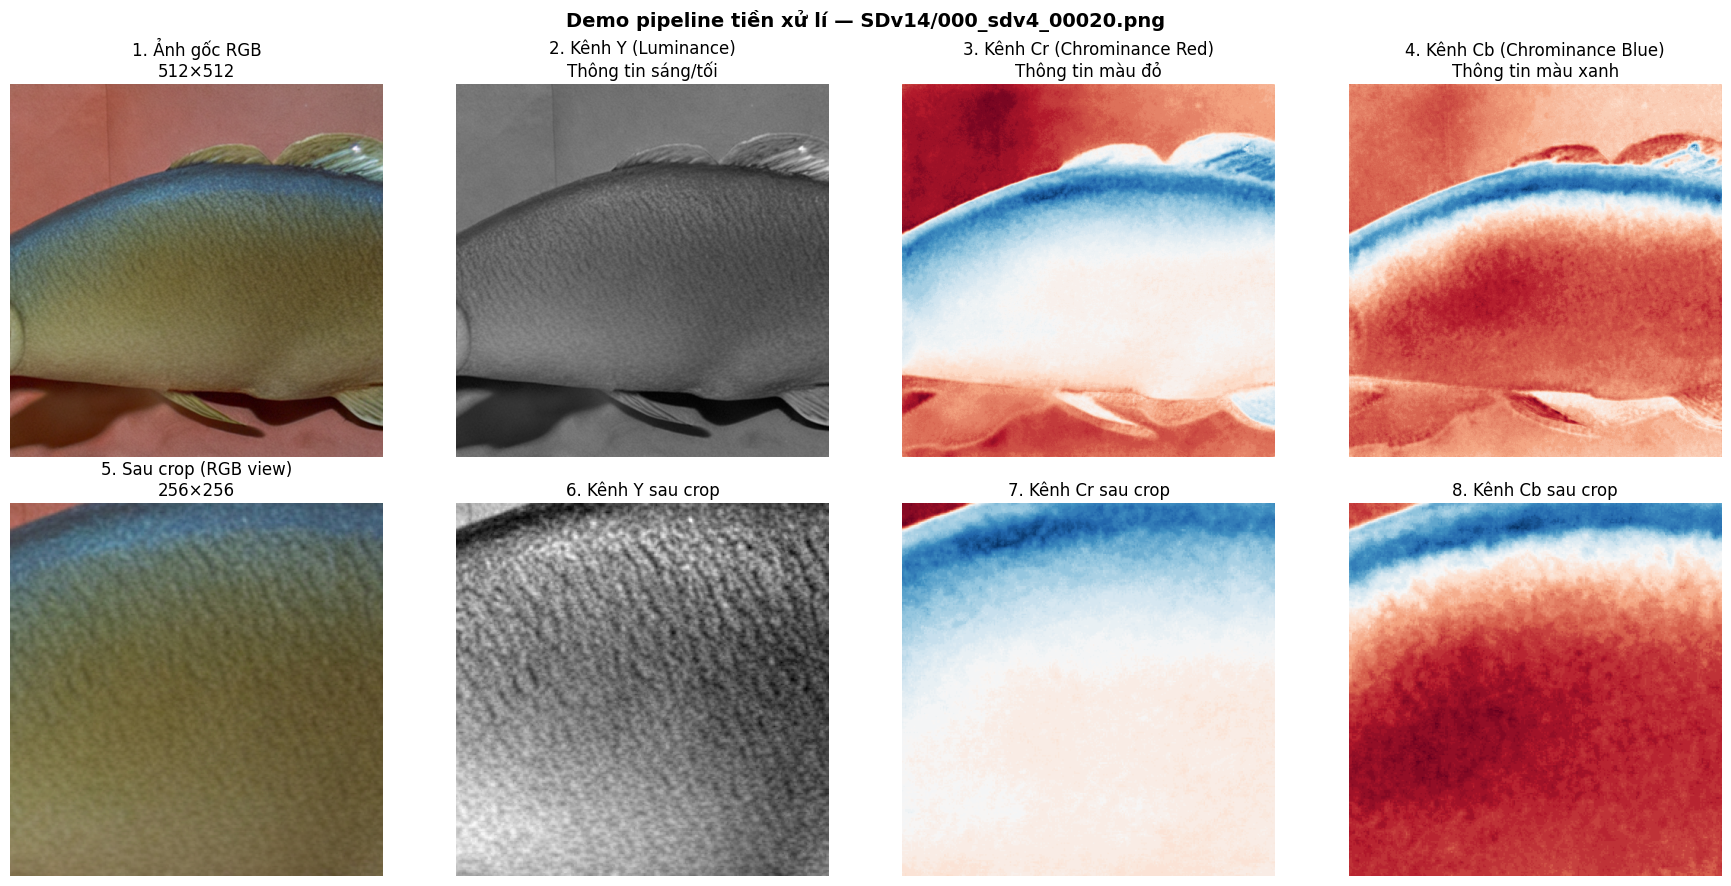

In [ ]:
# === 3.2 Demo từng bước xử lí trên 1 ảnh mẫu ===

# Lấy 1 ảnh fake từ SDv14 làm ví dụ
demo_gen = "SDv14"
demo_dir = os.path.join(RAW_FAKE, demo_gen)
demo_files = os.listdir(demo_dir)
demo_path = os.path.join(demo_dir, demo_files[0])

print(f"Ảnh mẫu: {demo_path}")

# B1: Đọc bằng PIL
pil_img = Image.open(demo_path)
pil_img = ImageOps.exif_transpose(pil_img)
pil_img = pil_img.convert("RGB")
img_rgb = np.array(pil_img)
print(f"Shape gốc (RGB): {img_rgb.shape}")

# B2: Chuyển BGR → YCrCb
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)

# B3: Center crop
h, w = img_ycrcb.shape[:2]
cy, cx = h // 2, w // 2
half = IMG_SIZE // 2
cropped = img_ycrcb[cy - half:cy + half, cx - half:cx + half]
print(f"Shape sau crop: {cropped.shape}")

# === VISUALIZATION ===
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Row 1: Ảnh gốc và chuyển đổi
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title(f"1. Ảnh gốc RGB\n{img_rgb.shape[1]}×{img_rgb.shape[0]}")

axes[0, 1].imshow(img_ycrcb[:,:,0], cmap='gray')
axes[0, 1].set_title("2. Kênh Y (Luminance)\nThông tin sáng/tối")

axes[0, 2].imshow(img_ycrcb[:,:,1], cmap='RdBu_r')
axes[0, 2].set_title("3. Kênh Cr (Chrominance Red)\nThông tin màu đỏ")

axes[0, 3].imshow(img_ycrcb[:,:,2], cmap='RdBu')
axes[0, 3].set_title("4. Kênh Cb (Chrominance Blue)\nThông tin màu xanh")

# Row 2: Sau crop
axes[1, 0].imshow(cv2.cvtColor(cropped, cv2.COLOR_YCrCb2RGB))
axes[1, 0].set_title(f"5. Sau crop (RGB view)\n{IMG_SIZE}×{IMG_SIZE}")

axes[1, 1].imshow(cropped[:,:,0], cmap='gray')
axes[1, 1].set_title(f"6. Kênh Y sau crop")

axes[1, 2].imshow(cropped[:,:,1], cmap='RdBu_r')
axes[1, 2].set_title(f"7. Kênh Cr sau crop")

axes[1, 3].imshow(cropped[:,:,2], cmap='RdBu')
axes[1, 3].set_title(f"8. Kênh Cb sau crop")

for ax in axes.flat:
    ax.axis('off')

plt.suptitle(f"Demo pipeline tiền xử lí — {demo_gen}/{demo_files[0]}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Xử lí batch toàn bộ dữ liệu

Áp dụng `process_image()` cho **toàn bộ** ảnh trong `data/raw/`. 

Quy tắc đặt tên output: `{generator}_{tên_gốc}.png` — tránh trùng filename giữa các generator.

Manifest: thu thập metadata cho mỗi ảnh thành công → lưu CSV.

⚠️ **Lưu ý**: Xóa dữ liệu processed cũ (từ lần chạy[:100] trước) trước khi chạy lại.

In [ ]:
# === 3.3a Xóa dữ liệu processed cũ ===
import shutil

for d in [PROC_REAL, PROC_FAKE]:
    if os.path.exists(d):
        old_count = len(os.listdir(d))
        shutil.rmtree(d)
        os.makedirs(d, exist_ok=True)
        print(f"Đã xóa {old_count} file cũ trong {d}")
    else:
        os.makedirs(d, exist_ok=True)

print("✓ Sẵn sàng chạy batch processing")

Đã xóa 15523 file cũ trong E:\ai_image_detector\data\processed\real
Đã xóa 0 file cũ trong E:\ai_image_detector\data\processed\fake
✓ Sẵn sàng chạy batch processing


In [ ]:
# === 3.3b Batch processing toàn bộ ảnh ===

manifest = []
stats = {"ok": 0, "quá nhỏ": 0, "nhỏ hơn 256": 0, "corrupt": 0, "lỗi khác": 0}
reject_details = []  # Lưu chi tiết ảnh bị loại

for label_name, raw_dir, proc_dir in [
    ("real", RAW_REAL, PROC_REAL),
    ("fake", RAW_FAKE, PROC_FAKE)
]:
    for gen in GENERATORS:
        gen_path = os.path.join(raw_dir, gen)
        if not os.path.isdir(gen_path):
            print(f"⚠️ Không tìm thấy: {gen_path}")
            continue
        
        files = os.listdir(gen_path)  # TOÀN BỘ, không giới hạn
        print(f"\n{label_name}/{gen}: {len(files)} ảnh", end=" → ")
        
        gen_ok = 0
        for fname in tqdm(files, desc=f"{gen}", leave=False):
            src_path = os.path.join(gen_path, fname)
            
            # Prefix generator vào tên file output để tránh trùng
            base_name = os.path.splitext(fname)[0]
            dst_fname = f"{gen}_{base_name}.png"
            dst_path = os.path.join(proc_dir, dst_fname)
            
            success, reason = process_image(src_path, dst_path)
            
            if success:
                stats["ok"] += 1
                gen_ok += 1
                manifest.append({
                    "path": dst_path,
                    "label": 0 if label_name == "real" else 1,
                    "label_name": label_name,
                    "generator": gen,
                    "filename": dst_fname,
                    "original": fname
                })
            else:
                # Phân loại lý do loại
                if "quá nhỏ" in reason:
                    stats["quá nhỏ"] += 1
                elif "nhỏ hơn" in reason:
                    stats["nhỏ hơn 256"] += 1
                elif "không đọc" in reason or "cannot" in reason.lower():
                    stats["corrupt"] += 1
                else:
                    stats["lỗi khác"] += 1
                
                reject_details.append({
                    "file": fname, "generator": gen,
                    "label": label_name, "reason": reason
                })
        
        print(f"{gen_ok}/{len(files)} OK")

print(f"\n{'=' * 55}")
print(f"KẾT QUẢ XỬ LÍ BATCH")
print(f"{'=' * 55}")
print(f"  Thành công:    {stats['ok']}")
print(f"  Quá nhỏ:       {stats['quá nhỏ']}")
print(f"  Nhỏ hơn 256:   {stats['nhỏ hơn 256']}")
print(f"  Corrupt:        {stats['corrupt']}")
print(f"  Lỗi khác:      {stats['lỗi khác']}")
print(f"  TỔNG bị loại:  {sum(v for k, v in stats.items() if k != 'ok')}")


real/ADM: 6000 ảnh → 

5829/6000 OK

real/GLIDE: 6000 ảnh → 

5840/6000 OK

real/Midjourney: 6000 ảnh → 

5379/6000 OK

real/SDv14: 6000 ảnh → 

5829/6000 OK

real/SDv15: 8000 ảnh → 

...

6000/6000 OK

fake/SDv14: 6000 ảnh → 

6000/6000 OK

fake/SDv15: 8000 ảnh → 

8000/8000 OK

fake/VQDM: 6000 ảnh → 

6000/6000 OK

fake/Wukong: 6000 ảnh → 

6000/6000 OK

KẾT QUẢ XỬ LÍ BATCH
  Thành công:    86326
  Quá nhỏ:       21
  Nhỏ hơn 256:   1653
  Corrupt:        0
  Lỗi khác:      0
  TỔNG bị loại:  1674


### 3.4 Lưu manifest CSV

Manifest = bảng quản lí dữ liệu. Mỗi dòng tương ứng 1 ảnh đã xử lí thành công:
- `path`: đường dẫn file output
- `label`: nhãn số (0=real, 1=fake)
- `label_name`: nhãn chữ
- `generator`: tên generator
- `filename`: tên file output
- `original`: tên file gốc

In [ ]:
# === 3.4 Lưu manifest CSV ===

df_manifest = pd.DataFrame(manifest)
manifest_path = os.path.join(PROC_DIR, "manifest.csv")
df_manifest.to_csv(manifest_path, index=False)

print(f"✓ Manifest đã lưu: {manifest_path}")
print(f"  Tổng số dòng: {len(df_manifest)}")
print(f"\nMẫu 5 dòng đầu:")
df_manifest.head()

✓ Manifest đã lưu: E:\ai_image_detector\data\processed\manifest.csv
  Tổng số dòng: 86326

Mẫu 5 dòng đầu:


,path,label,label_name,generator,filename,original
0,E:\ai_image_detector\data\processed\real\ADM_I...,0,real,ADM,ADM_ILSVRC2012_val_00000005.png,ILSVRC2012_val_00000005.JPEG
1,E:\ai_image_detector\data\processed\real\ADM_I...,0,real,ADM,ADM_ILSVRC2012_val_00000010.png,ILSVRC2012_val_00000010.JPEG
2,E:\ai_image_detector\data\processed\real\ADM_I...,0,real,ADM,ADM_ILSVRC2012_val_00000014.png,ILSVRC2012_val_00000014.JPEG
3,E:\ai_image_detector\data\processed\real\ADM_I...,0,real,ADM,ADM_ILSVRC2012_val_00000016.png,ILSVRC2012_val_00000016.JPEG
4,E:\ai_image_detector\data\processed\real\ADM_I...,0,real,ADM,ADM_ILSVRC2012_val_00000017.png,ILSVRC2012_val_00000017.JPEG


### 3.5 Validation dữ liệu sau tiền xử lí (processed)

Phần này tạo file `processed_validation.csv` để kiểm tra chất lượng ảnh output:
- Có đọc được hay không.
- Shape có đúng `256x256x3` không.
- Kiểu dữ liệu có phải `uint8` không.
- Pixel range có nằm trong `[0,255]` không.

Ngoài ra, cell này cũng tạo bảng so sánh **RAW vs PROCESSED** phục vụ phần trình bày trước/sau tiền xử lí.

In [ ]:
# === 3.5a Tạo processed_validation.csv ===

processed_rows = []

for _, row in df_manifest.iterrows():
    p = row["path"]
    img = cv2.imread(p, cv2.IMREAD_COLOR)
    read_ok = img is not None

    if read_ok:
        h, w, c = img.shape
        dtype = str(img.dtype)
        pmin, pmax = int(img.min()), int(img.max())
    else:
        h = w = c = None
        dtype = None
        pmin = pmax = None

    processed_rows.append({
        "path": p,
        "label_name": row["label_name"],
        "generator": row["generator"],
        "read_ok": read_ok,
        "shape_h": h,
        "shape_w": w,
        "shape_c": c,
        "dtype": dtype,
        "pixel_min": pmin,
        "pixel_max": pmax,
        "is_shape_256_256_3": bool(read_ok and (h, w, c) == (IMG_SIZE, IMG_SIZE, 3)),
        "is_uint8": bool(read_ok and str(img.dtype) == "uint8"),
        "is_range_0_255": bool(read_ok and pmin >= 0 and pmax <= 255),
    })


df_processed_val = pd.DataFrame(processed_rows)
processed_val_path = os.path.join(PROC_DIR, "processed_validation.csv")
df_processed_val.to_csv(processed_val_path, index=False)

print(f"✓ Đã lưu processed validation: {processed_val_path}")
print(f"  Tổng số dòng: {len(df_processed_val)}")

# Summary
pct_shape_ok = 100.0 * df_processed_val["is_shape_256_256_3"].mean() if len(df_processed_val) else 0.0
pct_uint8_ok = 100.0 * df_processed_val["is_uint8"].mean() if len(df_processed_val) else 0.0
pct_range_ok = 100.0 * df_processed_val["is_range_0_255"].mean() if len(df_processed_val) else 0.0

summary_processed = pd.DataFrame([
    {"metric": "processed_total", "value": len(df_processed_val)},
    {"metric": "processed_read_ok", "value": int(df_processed_val["read_ok"].sum())},
    {"metric": "processed_shape_ok_pct", "value": round(pct_shape_ok, 2)},
    {"metric": "processed_uint8_ok_pct", "value": round(pct_uint8_ok, 2)},
    {"metric": "processed_range_ok_pct", "value": round(pct_range_ok, 2)},
])

print("\n=== TÓM TẮT PROCESSED VALIDATION ===")
print(summary_processed.to_string(index=False))

print("\nPreview 10 dòng để chụp báo cáo:")
df_processed_val.head(10)

In [ ]:
# === 3.5b Bảng so sánh RAW vs PROCESSED (để đưa vào Word) ===

raw_ok = df_raw_audit[df_raw_audit["read_ok"] == True]
proc_ok = df_processed_val[df_processed_val["read_ok"] == True]

before_after = pd.DataFrame([
    {
        "criterion": "Số lượng file đọc được",
        "before_raw": int(raw_ok.shape[0]),
        "after_processed": int(proc_ok.shape[0]),
    },
    {
        "criterion": "Tỉ lệ có EXIF (%)",
        "before_raw": round(100.0 * raw_ok["has_exif"].mean(), 2) if len(raw_ok) else None,
        "after_processed": 0.0,
    },
    {
        "criterion": "Kích thước ảnh",
        "before_raw": "không đồng nhất",
        "after_processed": f"đồng nhất {IMG_SIZE}x{IMG_SIZE}",
    },
    {
        "criterion": "Kiểu dữ liệu pixel",
        "before_raw": "khác nhau theo nguồn",
        "after_processed": "uint8",
    },
    {
        "criterion": "Pixel range",
        "before_raw": "khác nhau theo nguồn",
        "after_processed": "[0,255]",
    },
    {
        "criterion": "Không gian màu dùng cho pipeline",
        "before_raw": "RGB/BGR phụ thuộc loader",
        "after_processed": "YCrCb",
    },
])

before_after_path = os.path.join(PROC_DIR, "before_after_comparison.csv")
before_after.to_csv(before_after_path, index=False)

print(f"✓ Đã lưu bảng so sánh trước/sau: {before_after_path}")
before_after

---
## Phần 4: Kiểm tra & Đánh giá sau tiền xử lí (Post-processing Validation)

### 4.1 Kiểm tra output: thống kê kết quả xử lí

Cần xác nhận:
- Bao nhiêu ảnh thành công / bị loại?
- Phân bố lý do loại bỏ?
- File output có đúng format không?

KIỂM TRA OUTPUT SAU XỬ LÍ
File trong processed/real/: 42326
File trong processed/fake/: 44000
File trong manifest.csv:    86326
Khớp nhau: ✓


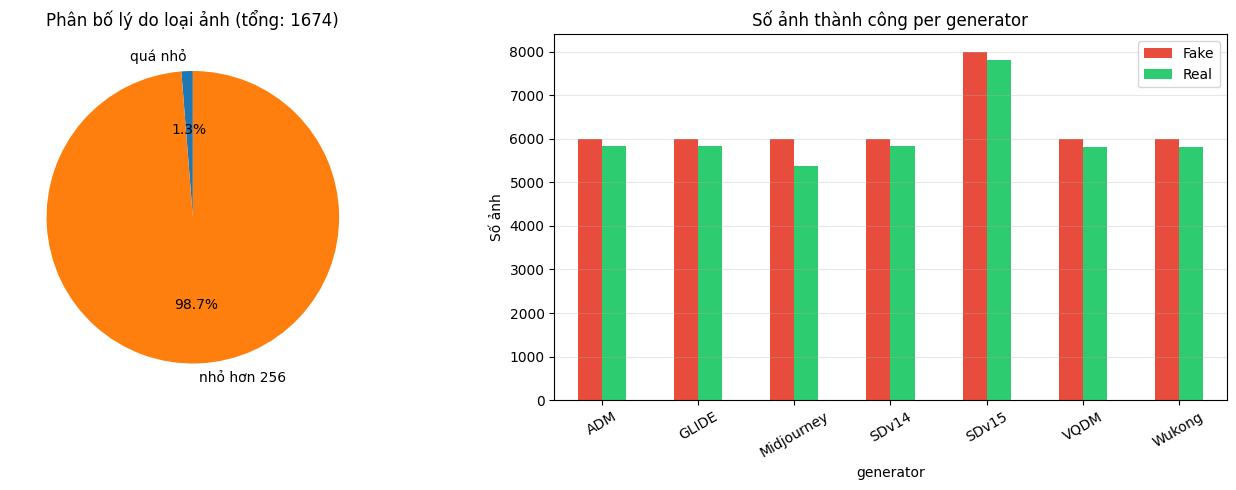

In [ ]:
# === 4.1 Thống kê kết quả xử lí ===

# Đếm file thực tế trong processed/
real_count = len(os.listdir(PROC_REAL))
fake_count = len(os.listdir(PROC_FAKE))

print("=" * 55)
print("KIỂM TRA OUTPUT SAU XỬ LÍ")
print("=" * 55)
print(f"File trong processed/real/: {real_count}")
print(f"File trong processed/fake/: {fake_count}")
print(f"File trong manifest.csv:    {len(df_manifest)}")
print(f"Khớp nhau: {'✓' if real_count + fake_count == len(df_manifest) else '✗'}")

# Pie chart: lý do loại bỏ
reject_counts = {k: v for k, v in stats.items() if k != "ok" and v > 0}

if reject_counts:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart lý do loại
    axes[0].pie(reject_counts.values(), labels=reject_counts.keys(),
                autopct='%1.1f%%', startangle=90)
    axes[0].set_title(f"Phân bố lý do loại ảnh (tổng: {sum(reject_counts.values())})")
    
    # Bar chart: success vs reject per generator
    gen_stats = df_manifest.groupby(["generator", "label_name"]).size().unstack(fill_value=0)
    gen_stats.plot(kind='bar', ax=axes[1], color=["#e74c3c", "#2ecc71"])
    axes[1].set_title("Số ảnh thành công per generator")
    axes[1].set_ylabel("Số ảnh")
    axes[1].legend(["Fake", "Real"])
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ Không có ảnh nào bị loại!")
    
    # Chỉ hiện bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    gen_stats = df_manifest.groupby(["generator", "label_name"]).size().unstack(fill_value=0)
    gen_stats.plot(kind='bar', ax=ax, color=["#e74c3c", "#2ecc71"])
    ax.set_title("Số ảnh xử lí thành công per generator")
    ax.set_ylabel("Số ảnh")
    ax.legend(["Fake", "Real"])
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 4.2 Validate ảnh đã xử lí

Kiểm tra random 10 ảnh output:
- Shape phải đúng `(256, 256, 3)`
- Dtype phải là `uint8`
- Pixel values trong khoảng `[0, 255]`

Kiểm tra 10 ảnh ngẫu nhiên:
----------------------------------------------------------------------
  Wukong_691_wukong_image128.png: ✓ shape=(256, 256, 3) | ✓ uint8 | ✓ range=[9,255]
  Wukong_825_wukong_image188.png: ✓ shape=(256, 256, 3) | ✓ uint8 | ✓ range=[0,255]
  SDv15_055_sdv5_00027.png: ✓ shape=(256, 256, 3) | ✓ uint8 | ✓ range=[0,255]
  ADM_655_adm_34.png: ✓ shape=(256, 256, 3) | ✓ uint8 | ✓ range=[0,252]
  ADM_ILSVRC2012_val_00002993.png: ✓ shape=(256, 256, 3) | ✓ uint8 | ✓ range=[0,255]
  VQDM_ILSVRC2012_val_00036572.png: ✓ shape=(256, 256, 3) | ✓ uint8 | ✓ range=[1,255]
  GLIDE_GLIDE_1000_200_05_551_glide_00035.png: ✓ shape=(256, 256, 3) | ✓ uint8 | ✓ range=[0,172]
  ADM_5_adm_34.png: ✓ shape=(256, 256, 3) | ✓ uint8 | ✓ range=[0,253]
  VQDM_VQDM_1000_200_01_161_vqdm_00143.png: ✓ shape=(256, 256, 3) | ✓ uint8 | ✓ range=[64,255]
  SDv15_ILSVRC2012_val_00026594.png: ✓ shape=(256, 256, 3) | ✓ uint8 | ✓ range=[16,255]
--------------------------------------------------------------

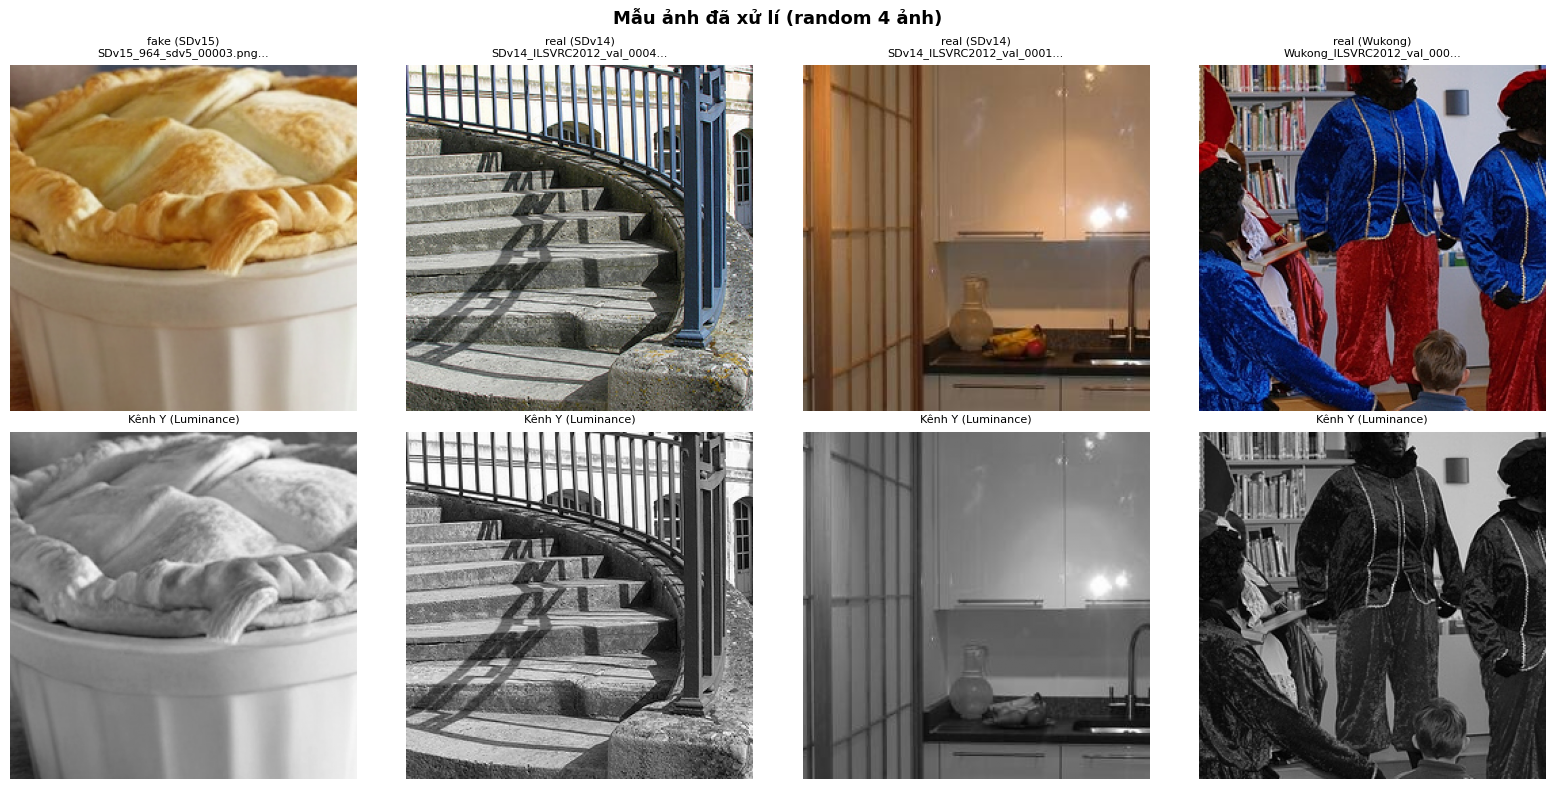

In [ ]:
# === 4.2 Validate ảnh output ===

sample_rows = df_manifest.sample(n=min(10, len(df_manifest)), random_state=42)
all_ok = True

print("Kiểm tra 10 ảnh ngẫu nhiên:")
print("-" * 70)

for _, row in sample_rows.iterrows():
    img = cv2.imread(row["path"])
    
    checks = []
    if img is None:
        checks.append("✗ Không đọc được!")
        all_ok = False
    else:
        # Check shape
        if img.shape == (IMG_SIZE, IMG_SIZE, 3):
            checks.append(f"✓ shape={img.shape}")
        else:
            checks.append(f"✗ shape={img.shape}")
            all_ok = False
        
        # Check dtype
        if img.dtype == np.uint8:
            checks.append("✓ uint8")
        else:
            checks.append(f"✗ dtype={img.dtype}")
            all_ok = False
        
        # Check pixel range
        if 0 <= img.min() and img.max() <= 255:
            checks.append(f"✓ range=[{img.min()},{img.max()}]")
        else:
            checks.append(f"✗ range=[{img.min()},{img.max()}]")
            all_ok = False
    
    print(f"  {row['filename']}: {' | '.join(checks)}")

print("-" * 70)
print(f"{'✓ Tất cả OK!' if all_ok else '✗ Có ảnh lỗi — cần kiểm tra lại!'}")

# Hiển thị 4 ảnh processed mẫu (ở dạng YCrCb channels)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
show_rows = df_manifest.sample(n=4, random_state=123)

for i, (_, row) in enumerate(show_rows.iterrows()):
    img = cv2.imread(row["path"])
    
    # Hàng 1: hiển thị dưới dạng RGB (convert ngược)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_YCrCb2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f"{row['label_name']} ({row['generator']})\n{row['filename'][:25]}...", fontsize=8)
    axes[0, i].axis('off')
    
    # Hàng 2: kênh Y (grayscale)
    axes[1, i].imshow(img[:,:,0], cmap='gray')
    axes[1, i].set_title("Kênh Y (Luminance)", fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("RGB view", fontsize=10)
axes[1, 0].set_ylabel("Y channel", fontsize=10)
plt.suptitle("Mẫu ảnh đã xử lí (random 4 ảnh)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Kiểm tra class balance sau tiền xử lí

Class balance ảnh hưởng trực tiếp đến hiệu suất model:
- Nếu **quá lệch** (ví dụ 90% fake, 10% real): model có thể đoán bừa "fake" và vẫn đạt accuracy cao
- Giải pháp nếu lệch: stratified sampling, class weight, SMOTE...

CLASS BALANCE SAU TIỀN XỬ LÍ

Tổng Real: 42326
Tổng Fake: 44000
Tỉ lệ Fake/Real: 1.04
✓ Dữ liệu tương đối cân bằng

Per-generator:
label_name  fake  real
generator             
ADM         6000  5829
GLIDE       6000  5840
Midjourney  6000  5379
SDv14       6000  5829
SDv15       8000  7804
VQDM        6000  5820
Wukong      6000  5825


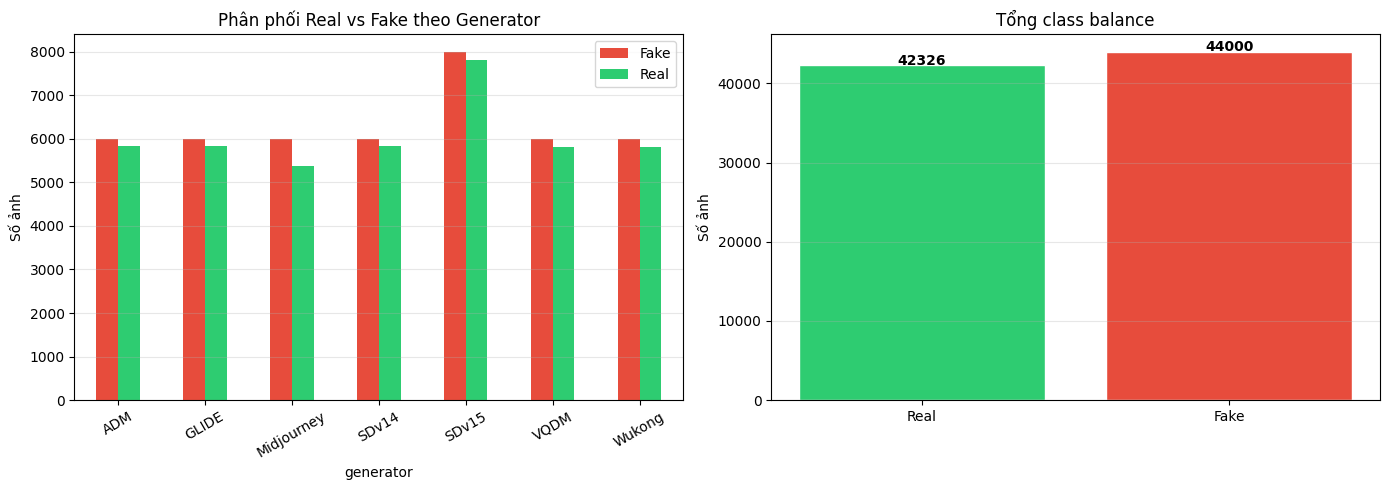

In [ ]:
# === 4.3 Class balance sau tiền xử lí ===

print("=" * 55)
print("CLASS BALANCE SAU TIỀN XỬ LÍ")
print("=" * 55)

# Tổng real vs fake
label_counts = df_manifest["label_name"].value_counts()
print(f"\nTổng Real: {label_counts.get('real', 0)}")
print(f"Tổng Fake: {label_counts.get('fake', 0)}")
ratio = label_counts.get('fake', 0) / max(label_counts.get('real', 0), 1)
print(f"Tỉ lệ Fake/Real: {ratio:.2f}")

if ratio > 2 or ratio < 0.5:
    print("⚠️ Dữ liệu KHÔNG CÂN BẰNG — cần xử lý (stratified split, class weight)")
else:
    print("✓ Dữ liệu tương đối cân bằng")

# Per-generator breakdown
print(f"\nPer-generator:")
gen_balance = df_manifest.groupby(["generator", "label_name"]).size().unstack(fill_value=0)
print(gen_balance.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart per generator
gen_balance.plot(kind='bar', ax=axes[0], color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Phân phối Real vs Fake theo Generator")
axes[0].set_ylabel("Số ảnh")
axes[0].legend(["Fake", "Real"])
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Overall balance
axes[1].bar(["Real", "Fake"], [label_counts.get('real', 0), label_counts.get('fake', 0)],
            color=["#2ecc71", "#e74c3c"], edgecolor='white')
axes[1].set_title("Tổng class balance")
axes[1].set_ylabel("Số ảnh")
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([label_counts.get('real', 0), label_counts.get('fake', 0)]):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.4 Train/Test Split (Stratified)

Chia dữ liệu thành **80% train** và **20% test** theo phương pháp **stratified** — đảm bảo:
- Mỗi generator xuất hiện cả trong train lẫn test
- Tỉ lệ real/fake giữ nguyên ở cả 2 phần
- Không bị rò rỉ dữ liệu (data leakage): ảnh cùng nguồn không xuất hiện cả 2 bên

**Tại sao stratified split?**
- Nếu chia random, có thể 1 generator chỉ nằm trong train → model không biết test với generator đó
- Stratified giữ phân phối đều → đánh giá công bằng hơn

In [ ]:
# === 4.4 Train/Test Split ===
from sklearn.model_selection import train_test_split

# Stratify theo cả label + generator
df_manifest["stratify_col"] = df_manifest["label_name"] + "_" + df_manifest["generator"]

df_train, df_test = train_test_split(
    df_manifest, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_manifest["stratify_col"]
)

# Xóa cột tạm
df_train = df_train.drop(columns=["stratify_col"])
df_test = df_test.drop(columns=["stratify_col"])
df_manifest = df_manifest.drop(columns=["stratify_col"])

# Lưu
train_path = os.path.join(PROC_DIR, "manifest_train.csv")
test_path = os.path.join(PROC_DIR, "manifest_test.csv")
df_train.to_csv(train_path, index=False)
df_test.to_csv(test_path, index=False)

print(f"✓ Train set: {len(df_train)} ảnh → {train_path}")
print(f"✓ Test set:  {len(df_test)} ảnh  → {test_path}")

# Bảng phân phối train vs test
print(f"\nPhân phối per generator:")
print("-" * 60)

for gen in GENERATORS:
    train_real = len(df_train[(df_train['generator'] == gen) & (df_train['label'] == 0)])
    train_fake = len(df_train[(df_train['generator'] == gen) & (df_train['label'] == 1)])
    test_real = len(df_test[(df_test['generator'] == gen) & (df_test['label'] == 0)])
    test_fake = len(df_test[(df_test['generator'] == gen) & (df_test['label'] == 1)])
    print(f"  {gen:12s} | Train: {train_real:5d} real, {train_fake:5d} fake | Test: {test_real:4d} real, {test_fake:4d} fake")

print("-" * 60)
print(f"  {'TỔNG':12s} | Train: {len(df_train[df_train['label']==0]):5d} real, {len(df_train[df_train['label']==1]):5d} fake | "
      f"Test: {len(df_test[df_test['label']==0]):4d} real, {len(df_test[df_test['label']==1]):4d} fake")

✓ Train set: 69060 ảnh → E:\ai_image_detector\data\processed\manifest_train.csv
✓ Test set:  17266 ảnh  → E:\ai_image_detector\data\processed\manifest_test.csv

Phân phối per generator:
------------------------------------------------------------
  ADM          | Train:  4663 real,  4800 fake | Test: 1166 real, 1200 fake
  GLIDE        | Train:  4672 real,  4800 fake | Test: 1168 real, 1200 fake
  Midjourney   | Train:  4303 real,  4800 fake | Test: 1076 real, 1200 fake
  SDv14        | Train:  4663 real,  4800 fake | Test: 1166 real, 1200 fake
  SDv15        | Train:  6243 real,  6400 fake | Test: 1561 real, 1600 fake
  VQDM         | Train:  4656 real,  4800 fake | Test: 1164 real, 1200 fake
  Wukong       | Train:  4660 real,  4800 fake | Test: 1165 real, 1200 fake
------------------------------------------------------------
  TỔNG         | Train: 33860 real, 35200 fake | Test: 8466 real, 8800 fake


---
### 4.5 Tóm tắt Pipeline Tiền Xử Lí

| Bước | Thao tác | Ý nghĩa |
|------|----------|---------|
| **EDA** | Đếm ảnh, kiểm tra kích thước, trùng lặp, pixel stats | Hiểu dữ liệu trước khi xử lí |
| **Fix orientation** | `PIL.ImageOps.exif_transpose()` | Ảnh luôn đúng chiều |
| **Strip metadata** | Chuyển PIL → numpy array | Model học từ pixel, không metadata |
| **Color space** | BGR → YCrCb | Y tách sáng (tốt cho FFT/GLCM), Cr/Cb tách màu |
| **Center crop** | Crop vùng giữa 256×256 | Đồng nhất kích thước, giữ pixel gốc |
| **Lưu PNG** | Lossless format | Không thêm artifact nén |
| **Manifest** | CSV metadata | Quản lí dữ liệu có hệ thống |
| **Stratified split** | 80/20 theo label + generator | Đánh giá công bằng, tránh data leakage |

**Kết quả**: Dữ liệu đã chuẩn hóa, sẵn sàng cho bước **trích xuất đặc trưng** (Notebook 02).

In [ ]:
import numpy as np
import pandas as pd

pth = "E:\\ai_image_detector\\features\\X_test.npy"
test = np.load(pth)

# Load feature names nếu có
feature_names_path = "E:\\ai_image_detector\\features\\feature_names.txt"
with open(feature_names_path) as f:
    feature_names = [line.strip() for line in f.readlines()]

df = pd.DataFrame(test, columns=feature_names)
print(df.shape)
df.head()


(17266, 57)


,fft_low_energy_mean,fft_low_energy_std,fft_low_energy_p90,fft_mid_energy_mean,fft_mid_energy_std,fft_mid_energy_p90,fft_high_energy_mean,fft_high_energy_std,fft_high_energy_p90,fft_high_low_ratio_mean,...,stat_mean_p90,stat_std_mean,stat_std_std,stat_std_p90,stat_skew_mean,stat_skew_std,stat_skew_p90,stat_kurtosis_mean,stat_kurtosis_std,stat_kurtosis_p90
0,7.586700,0.178789,7.804105,6.722905,0.145679,6.898302,6.284672,0.121172,6.430844,0.828575,...,121.047607,25.460477,3.186090,28.625917,0.627056,0.389510,1.051010,0.692655,0.886332,1.538058
1,8.008339,0.221871,8.227559,6.639871,0.445010,7.053349,5.828599,0.494848,6.344206,0.726873,...,164.637451,55.122636,16.807816,85.896827,0.475843,0.513277,1.009247,-0.270769,1.052752,0.682710
2,6.792730,0.208563,6.982980,5.092442,0.208415,5.351867,4.347067,0.181220,4.542097,0.640034,...,124.579712,29.976964,8.520155,39.871242,-0.058353,1.385135,1.563508,1.674826,4.342002,5.097062
3,7.199872,0.621123,7.666261,5.936039,0.651335,6.431656,4.998350,0.611730,5.436003,0.691970,...,131.773560,37.766278,9.942698,52.045286,0.656366,0.623113,1.478254,0.482360,1.542494,3.233435
4,5.737135,0.658798,6.411330,4.595131,0.477340,5.068516,4.121680,0.398382,4.486328,0.721269,...,35.190308,8.519121,4.343887,13.539330,1.860303,1.986734,3.800444,10.112662,19.923781,20.256222
